In [1]:
## Uncomment to install starcat package
# !pip install starcatpy

In [2]:
import sys 
import os
sys.path.append("../../")

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, false_discovery_control
import muon as mu
import scirpy as ir
from starcat import starCAT

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="mudata")

/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


In [3]:
%load_ext autoreload
%autoreload 2

# Set up

In [4]:
# ground truth and HLA per dextramer
dex_map ={"HLA-A*0201": "DexA", "HLA-C*0702":"DexC", "HLA-B*0801":"DexN", "HLA-B*0702":"DexB"}
dex_map_rev ={"DexA":"HLA-A*0201", "DexC":"HLA-C*0702", "DexN":"HLA-B*0801", "DexB":"HLA-B*0702"}
dex_info = {
    'DexA': {'ground_truth': 'NLV_true', 'HLA-match': 'D2'},
    'DexB': {'ground_truth': 'TPR_true', 'HLA-match': 'D1'},
    'DexC': {'ground_truth': 'CRV_true', 'HLA-match': 'D1'},
    
}

In [5]:
sns.reset_defaults()

fs = 14
global_settings = {
'font.size': fs, 'axes.titlesize': 'medium', 'axes.labelsize': 'medium', 'xtick.labelsize': 'medium', 'ytick.labelsize': 'medium', 'legend.fontsize': 'medium', 'figure.titlesize': 'medium',
    'figure.figsize': (3, 2.5), 'figure.dpi': 100, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.transparent': True,
}
plt.rcParams.update(global_settings)
os.makedirs('figures', exist_ok=True)

hue_order = ['ICON-code', 'ICON', 'ITRAP', 'BEAM', 'DextraDemixer']
method_palette = {'ITRAP': "#ffeb11", 'ICON-code':'#f3b37a', 'ICON': "#ffa52e", 'BEAM': "#02c102", 'DextraDemixer': "#8900bf"}
classification_palette = { 'True Negative': 'lightgray', 'True Positive': '#8DB4E2', 'False Positive': '#FF4500', 'False Negative': '#C00000', 'excluded': 'whitesmoke'}
classification_palette_brief = { 'TN': 'lightgray', 'TP': '#8DB4E2', 'FP': '#FF4500', 'FN': '#C00000', 'excluded': 'whitesmoke'}

plt.rcParams.update({ 'axes.spines.top': False, 'axes.spines.right': False, })

In [6]:
def get_cm(y_true, y_pred, adata, method):
    mask = ~np.isnan(y_true)
    adata.obs[method] = pd.Categorical(['excluded' for i in range(adata.n_obs)], categories = ['TP','TN','FN','FP', 'excluded'])
    adata.obs.loc[mask,method] = np.where(y_true[mask]==1, np.where(y_pred[mask]==1, 'TP', 'FN'), np.where(y_pred[mask]==1, 'FP', 'TN'))
    return

def plot_confusion_hist(x_umi, ground_truth, assignment, title='', ax=None, legend=True):
    mask = ~np.isnan(ground_truth)
    confusion_df = pd.DataFrame({'UMI counts': x_umi[mask], 'True': ground_truth[mask], 'Predicted': assignment[mask]})
    conditions = [ (confusion_df['True'] == 0.0) & (confusion_df['Predicted'] == 0.0), (confusion_df['True'] == 1.0) & (confusion_df['Predicted'] == 1.0), (confusion_df['True'] == 0.0) & (confusion_df['Predicted'] == 1.0), (confusion_df['True'] == 1.0) & (confusion_df['Predicted'] == 0.0) ]
    choices = [ 'True Negative', 'True Positive', 'False Positive', 'False Negative' ]
    confusion_df['Outcome'] = np.select(conditions, choices, default='Unknown')   
    ax = sns.histplot(
        data=confusion_df, x='UMI counts', hue='Outcome', palette=classification_palette, hue_order=choices, bins=30, 
        multiple="stack", edgecolor="white", linewidth=0.5, ax=ax
    )
    if legend:
        sns.move_legend(ax, 'upper left', bbox_to_anchor=(0.3, 1), frameon=False, ncols=1, )
    else:
        ax.legend().remove()
    ax.set_title(title, pad=5)
    ax.set_yscale('log')
    sns.despine()
    return ax

def plot_umap(adata, ax, color):
    dt = pd.DataFrame(adata.mod['rna'].obsm['wnn.umap'], columns=['UMAP1', 'UMAP2'])
    dt[color] = adata.obs[color].values
    dt[color] = pd.Categorical(dt[color], categories=['FN','FP','TP','TN','excluded'])
    dt = dt.sort_values(color, ascending=False)

    ax = sns.scatterplot(
        dt, x='UMAP1', y='UMAP2', hue=color, ax=ax,
        palette=classification_palette_brief, 
        s=1, linewidth=0.1, hue_order=['FN','FP','TP','TN','excluded']
    )
    ax = sns.scatterplot(
        dt[dt[color].isin(['FN','FP','TP'])], x='UMAP1', y='UMAP2', hue=color, ax=ax,
        palette=classification_palette_brief, 
        s=10, linewidth=0.1, hue_order=['FN','FP','TP','TN','excluded']
    )
    ax.legend().remove()
    ax.set(xticks=[], yticks=[], xlabel='', ylabel='')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_axis_off()
    return ax


# Prepare data

In [7]:
mdata_wTCR = mu.read("../../data/Gemund_wTCR_wPredictions.h5mu")
mdata_wTCR

/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


MuData object with n_obs × n_vars = 2835 × 20154
  obs:	'VDJ_1_umi_count', 'VJ_1_umi_count', 'VDJ_2_umi_count', 'VJ_2_umi_count', 'NLV_true', 'CRV_true', 'TPR_true', 'dextrademixer_DexA', 'dextrademixer_DexA_p', 'DextraDemixer_DexA', 'DextraDemixer_DexA_p', 'BEAM_DexA', 'BEAM_DexA_p', 'dextrademixer_DexC', 'dextrademixer_DexC_p', 'DextraDemixer_DexC', 'DextraDemixer_DexC_p', 'BEAM_DexC', 'BEAM_DexC_p', 'dextrademixer_DexB', 'dextrademixer_DexB_p', 'DextraDemixer_DexB', 'DextraDemixer_DexB_p', 'BEAM_DexB', 'BEAM_DexB_p', 'itrap_pMHC_assignment', 'ICON_DexA', 'ICON_DexC', 'ICON_DexB', 'ICON-code_DexA', 'ICON-code_DexC', 'ICON-code_DexB', 'ITRAP_DexA', 'ITRAP_DexB', 'ITRAP_DexN', 'ITRAP_DexC'
  uns:	'Cell_colors', 'Dex_colors', 'Sample_colors', 'cartridge_colors', 'cluster_colors', 'pca'
  obsm:	'AB', 'HTO', 'HTOflex', 'RNA', 'RiO', 'RiO_bg', 'X_pca', 'X_umap', 'X_wnn.umap', 'itrap_pMHC_assignment', 'wnn.umap'
  varm:	'AB', 'HTO', 'HTOflex', 'PCs', 'RNA', 'RiO', 'RiO_bg'
  obsp:	'wknn', 'wsnn'
  7 modalities
    airr:	2835 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'cluster', 'Dex', 'clone_id', 'clone_id_size', 'antigen.species', 'antigen.gene'
      uns:	'chain_indices', 'clone_id', 'clonotype_network', 'ir_dist_VDJDB_aa_identity', 'ir_dist_nt_identity', 'ir_query_VDJDB_aa_identity', 'scirpy_version'
      obsm:	'X_clonotype_network', 'airr', 'chain_indices'
    rna:	2835 x 20107
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_HTOflex', 'nFeature_HTOflex', 'nReads_ALL', 'nReads_RNA', 'percent.mito', 'meanCount_RNA', 'meanCount_HTO', 'meanCount_HTOflex', 'HTOflex_maxID', 'HTOflex_secondID', 'HTOflex_margin', 'HTOflex_classification', 'HTOflex_classification.global', 'hash.ID', 'hash.ID.flex', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'tag.no', 'Sample', 'SpikeIn.pct', 'Background', 'Background.Donor', 'Background.pct', 'flex.tag.no', 'Cell', 'Type', 'Donor', 'Donor.long', 'Origin', 'Specificity', 'peptide.stim', 'CMV.peptide', 'Peptide.Seq', 'HLA.A.02.01', 'HLA.B.07.02', 'HLA.C.07.02', 'nCount_AB', 'nFeature_AB', 'nCount_RiO', 'nFeature_RiO', 'cartridge', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.0.5', 'seurat_clusters', 'nCount_SCT', 'nFeature_SCT', 'SCT.weight', 'AB.weight', 'wsnn_res.0.5', 'wsnn_res.0.5_anno', 'wsnn_res.0.5_old', 'wsnn_res.0.52', 'wsnn_res.0.52_anno', 'nCount_RiO_bg', 'nFeature_RiO_bg', 'cell_id', 'DexA', 'DexB', 'DexC', 'Dex', 'flex_tag_label', 'cluster', 'category'
      var:	'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'highly_variable'
      uns:	'pca'
      obsm:	'X_pca', 'wnn.umap'
      varm:	'PCs'
      layers:	'counts', 'data'
    ab:	2835 x 31
      var:	'highly_variable'
      uns:	'apca'
      obsm:	'X_apca'
      varm:	'apca'
      layers:	'counts', 'data'
    rio:	2835 x 4
      layers:	'counts'
    rio_bg:	2835 x 3
      layers:	'counts', 'data'
    hto:	2835 x 4
      layers:	'counts'
    hto_flex:	2835 x 5
      layers:	'counts'

In [8]:
metrics_list = ['f1','precision','recall','accuracy']
results_merged = pd.read_csv('results/predictions.csv')
results_melt = results_merged.sort_values(['setting', 'model_config']).melt(
    id_vars=['model_config', 'setting'], value_vars=metrics_list, var_name='metric', value_name='value'
)
results_melt.head(3)

,model_config,setting,metric,value
0,BEAM,DexA 5% (all cells),f1,0.913043
1,DextraDemixer,DexA 5% (all cells),f1,0.933333
2,BEAM,DexA 5% (has TCR),f1,1.000000


# Summary statistics

In [9]:
mdata_wTCR.obs.loc[mdata_wTCR.obs['rna:Sample']=='50-50-D2',['rna:flex_tag_label','NLV_true']].value_counts()

rna:flex_tag_label  NLV_true
BG_D2               0.0         413
TPR_enriched        0.0         100
CRV_Clone           0.0          45
NLV_Clone           1.0          29
Name: count, dtype: int64

In [10]:
# NLV - 05-95-D2 & 50-50-D2
mdata_wTCR.obs[['rna:Sample','NLV_true']].value_counts().reset_index().pivot(columns='NLV_true', values='count', index='rna:Sample')

NLV_true,0.0,1.0
rna:Sample,,
05-95-D1,12,4
05-95-D2,828,7
50-50-D1,131,24
50-50-D2,558,29


In [11]:
# CRV - 05-95-D1 & 50-50-D1
mdata_wTCR.obs[['rna:Sample','CRV_true']].value_counts().reset_index().pivot(columns='CRV_true', values='count', index='rna:Sample')

CRV_true,0.0,1.0
rna:Sample,,
05-95-D1,706,3
05-95-D2,17,12
50-50-D1,654,49
50-50-D2,129,45


In [12]:
# TPR - 05-95-D1 & 50-50-D1
mdata_wTCR.obs[['rna:Sample','TPR_true']].value_counts().reset_index().pivot(columns='TPR_true', values='count', index='rna:Sample')

TPR_true,0.0,1.0
rna:Sample,,
05-95-D1,704,5
05-95-D2,24,5
50-50-D1,671,32
50-50-D2,130,44


# Benchmarking results

## Per method plots

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2621816762.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2621816762.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2621816762.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2163547656.py:22: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough t

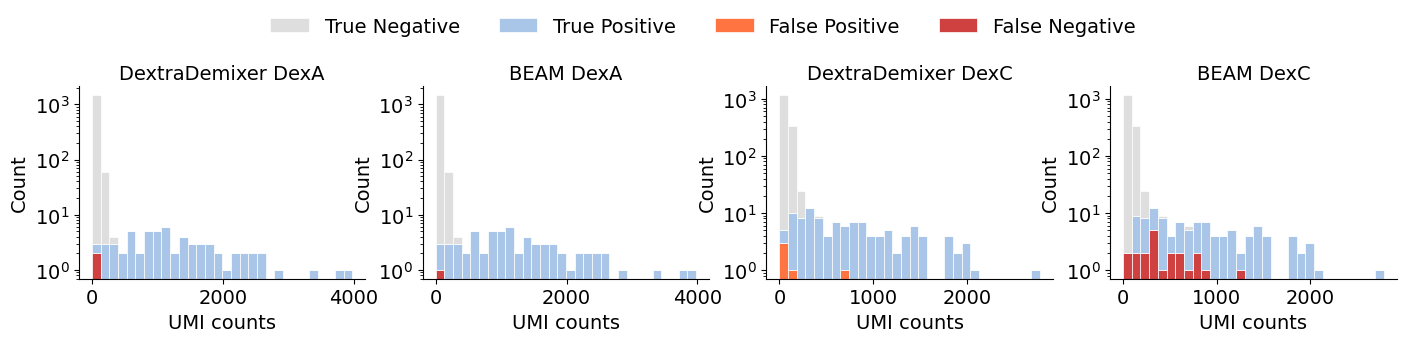

In [13]:
methods = ['DextraDemixer', 'BEAM']
fig, axes = plt.subplots(ncols=4, figsize=(17, 2.5))

i = 0
for dextramer in ['DexA', 'DexC']:
    for method in methods:
        x_umi = mdata_wTCR.mod['rio'][:,dex_map_rev[dextramer]].X.toarray()[:, 0]
        
        # get predictions
        ytrue = mdata_wTCR.obs[dex_info[dextramer]['ground_truth']].values
        ypred = mdata_wTCR.obs[f'{method}_{dextramer}'].values
        
        # plots
        if i != 3:
            axes[i] = plot_confusion_hist(x_umi, ytrue, ypred, ax=axes[i], legend=False, title=f'{method} {dextramer}')
        else:
            axes[i] = plot_confusion_hist(x_umi, ytrue, ypred, ax=axes[i], legend=True, title=f'{method} {dextramer}')
            sns.move_legend(axes[i], 'upper right', frameon=False, title='', fontsize=fs, ncol=4, bbox_to_anchor=(0.15, 1.45))
        i += 1

        
plt.tight_layout()
plt.savefig('../../figures/3c.svg')
plt.show()

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2621816762.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2621816762.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2621816762.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2621816762.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose labe

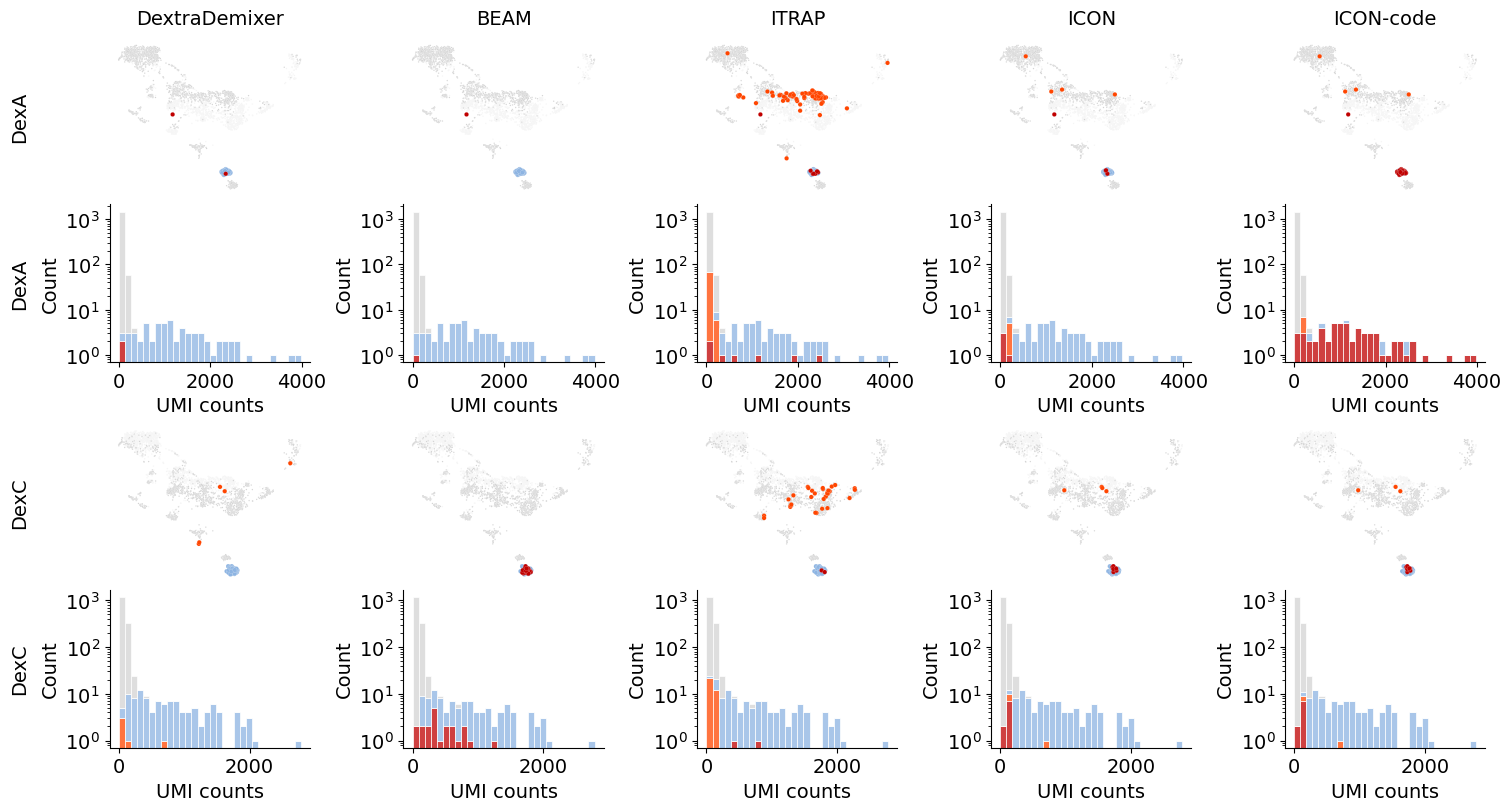

In [14]:
methods = ['DextraDemixer','BEAM', 'ITRAP', 'ICON', 'ICON-code']
fig, axes = plt.subplots(4, len(methods), figsize=(len(methods)*3, 4*2), constrained_layout=True)

for dextramer in ['DexA', 'DexC']:
    base_i = 0 if dextramer == 'DexA' else 2
    axes[base_i,0].annotate(dextramer, xy=(-0.45, 0.5), xycoords='axes fraction', rotation=90, va='center', ha='center', fontsize=fs)
    axes[base_i+1,0].annotate(dextramer, xy=(-0.45, 0.5), xycoords='axes fraction', rotation=90, va='center', ha='center', fontsize=fs)    
    x_umi = mdata_wTCR.mod['rio'][:,dex_map_rev[dextramer]].X.toarray()[:, 0]

    for i, method in enumerate(methods): 
        # get predictions
        ytrue = mdata_wTCR.obs[dex_info[dextramer]['ground_truth']].values
        ypred = mdata_wTCR.obs[f'{method}_{dextramer}'].values
        get_cm(ytrue, ypred, mdata_wTCR, method) # transfer conf matrix to adata
        
        # plots
        axes[base_i,i] = plot_umap(mdata_wTCR, ax=axes[base_i,i], color=method)
        if base_i == 0:
            axes[base_i, i].set_title(method, fontsize=fs, pad=10)
        axes[base_i+1,i] = plot_confusion_hist(x_umi, ytrue, ypred, ax=axes[base_i+1,i], legend=False)

#plt.tight_layout(h_pad=0)
plt.savefig('../../figures/S3b.png', dpi=150)

plt.show()

### Boxplots per metric

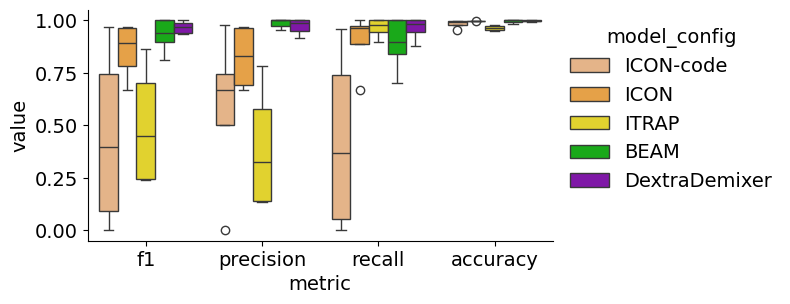

In [15]:
plt.figure(figsize=(6, 3))
ax = sns.boxplot(
    data=results_melt, x='metric', y='value', hue='model_config', palette=method_palette, order=metrics_list, hue_order=hue_order
)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.show()

In [16]:
results_melt.groupby(['metric','model_config'])['value'].mean()

metric     model_config 
accuracy   BEAM             0.994440
           DextraDemixer    0.997744
           ICON             0.996122
           ICON-code        0.983309
           ITRAP            0.963167
f1         BEAM             0.931489
           DextraDemixer    0.966281
           ICON             0.853724
           ICON-code        0.440185
           ITRAP            0.499500
precision  BEAM             0.986680
           DextraDemixer    0.971506
           ICON             0.822842
           ICON-code        0.578125
           ITRAP            0.392375
recall     BEAM             0.888184
           DextraDemixer    0.963030
           ICON             0.897842
           ICON-code        0.423704
           ITRAP            0.963934
Name: value, dtype: float64

### Barplots per setting

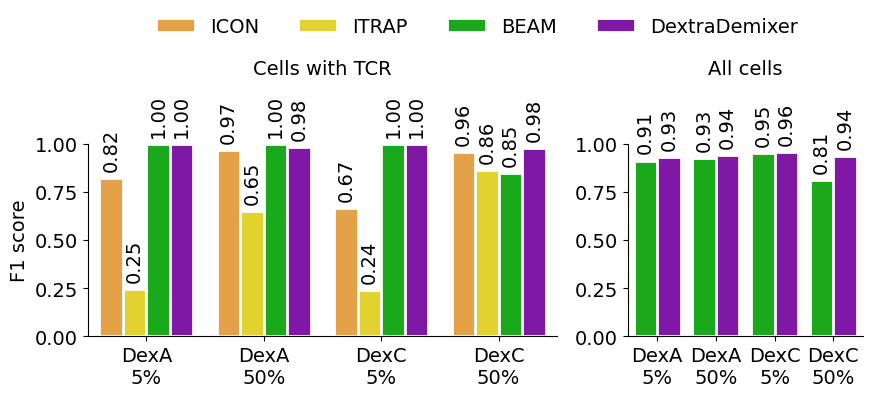

In [17]:
results_merged = results_merged.sort_values(['setting', 'model_config'])
results_merged['setting_clean'] = results_merged.setting.apply(lambda x: x.split(' (')[0])
results_merged['setting_clean'] = results_merged.setting_clean.str.replace(' ','\n') 

str_list = ['has TCR', 'all cells']
fig, axes = plt.subplots(1, 2, figsize=(10, 2.5), gridspec_kw={'width_ratios': [2, 1]})

for i, cellset in enumerate(str_list):
    dt = results_merged[results_merged.setting.str.contains(cellset)]
    dt = dt[dt.model_config != 'ICON-code']
    axes[i] = sns.barplot(
        dt, x='setting_clean', y='f1', hue='model_config', hue_order=[h for h in hue_order if h in dt.model_config.unique()],
        palette=method_palette, width=0.8, edgecolor='white', linewidth=2, ax=axes[i]
    )
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.2f", fontsize=fs, label_type='edge', padding=5, rotation=90)

    if i == 0:
        sns.move_legend(axes[i], 'upper right', frameon=False, title='', fontsize=fs, ncol=4, bbox_to_anchor=(1.55, 1.75))
        axes[i].set_ylabel('F1 score', fontsize=fs)
    else:
        axes[i].legend().remove()
        axes[i].set_ylabel('')
        
    axes[i].set_title('Cells with TCR' if i == 0 else 'All cells', fontsize=fs, pad=50)
    axes[i].set_ylim(0,1)
    axes[i].tick_params(axis='x', labelsize=fs)
    axes[i].tick_params(axis='y', labelsize=fs)

    axes[i].set_xlabel('')
    sns.despine(ax=axes[i])
    
plt.savefig('../../figures/3b.svg')
plt.show()

### Head-to-head scatter

In [18]:
results_dextrademixer = results_merged[results_merged.model_config == 'DextraDemixer']
results_dextrademixer.index = results_dextrademixer.setting
results_dextrademixer = results_dextrademixer.iloc[:,5:]
results_dextrademixer.columns = 'DextraDemixer_' + results_dextrademixer.columns 
results_scatter = results_merged[results_merged.model_config != 'DextraDemixer']
results_scatter.loc[:,results_dextrademixer.columns] = results_dextrademixer.loc[results_scatter.setting,:].values

### Clip

/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2545659685.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_scatter.loc[:,'y_plot'] = results_scatter[f'DextraDemixer_{metric}'].clip(vmin+pad, vmax-pad)
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2545659685.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_scatter.loc[:,'x_plot'] = results_scatter[metric].clip(vmin+pad, vmax-pad)
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/2545

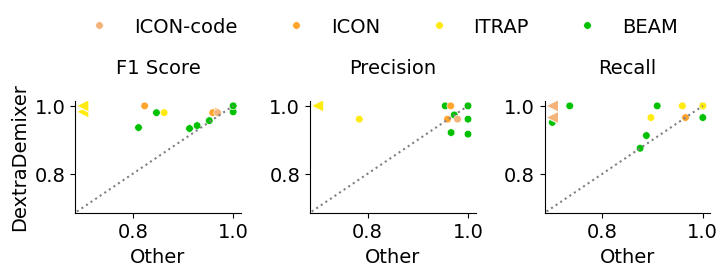

In [19]:
metrics = ['f1', 'precision', 'recall', ]
title_map = {'pr_auc': 'PR AUC', 'roc_auc': 'ROC AUC', 'f1': 'F1 Score', 'precision': 'Precision', 'recall': 'Recall', 'accuracy': 'Accuracy'}

fig, axes = plt.subplots(1, len(metrics), figsize=(2.5 * len(metrics), 2.5))
legend_handles, legend_labels = None, None
vmin, vmax = 0.7, 1
pad = 0.05 * (vmax - vmin)
vmin, vmax = (vmin - pad, vmax + pad)

for i, metric in enumerate(metrics):
    results_scatter.loc[:,'y_plot'] = results_scatter[f'DextraDemixer_{metric}'].clip(vmin+pad, vmax-pad)
    results_scatter.loc[:,'x_plot'] = results_scatter[metric].clip(vmin+pad, vmax-pad)
    results_scatter.loc[:,'clipped'] = (
        (results_scatter[f'DextraDemixer_{metric}'] < vmin) | (results_scatter[f'DextraDemixer_{metric}'] > vmax) |
        (results_scatter[metric] < vmin) | (results_scatter[metric] > vmax)
    )

    axes[i] = sns.scatterplot(
        results_scatter[~results_scatter.clipped], x='x_plot', y='y_plot', 
        ax=axes[i], legend=(i == 0), hue='model_config', palette=method_palette,
        s=30, hue_order=[h for h in hue_order if h in results_scatter.model_config.unique()]
    )
    axes[i] = sns.scatterplot(
        results_scatter[results_scatter.clipped], x='x_plot', y='y_plot',
        ax=axes[i], legend=False, hue='model_config', palette=method_palette, s=80, marker='<',
        hue_order=[h for h in hue_order if h in results_scatter.model_config.unique()]
    )
    if i == 0:
        legend_handles, legend_labels = axes[i].get_legend_handles_labels()
        if axes[i].legend_ is not None:
            axes[i].legend_.remove()

    diff = vmax - vmin
    axes[i].plot((vmin - diff * 0.1, 1), (vmin - diff * 0.1, 1), ls=':', c='grey')
    axes[i].set_title(title_map[metric], pad=20)
    axes[i].set_xlabel('Other')
    axes[i].set_ylim(vmin,vmax)
    axes[i].set_xlim(vmin,vmax)
    axes[i].set_ylabel('DextraDemixer' if i == 0 else '')

fig.legend(legend_handles, legend_labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.52, 1.15))

plt.tight_layout()
plt.savefig('../../figures/S3a.svg')
plt.show()

# TPR

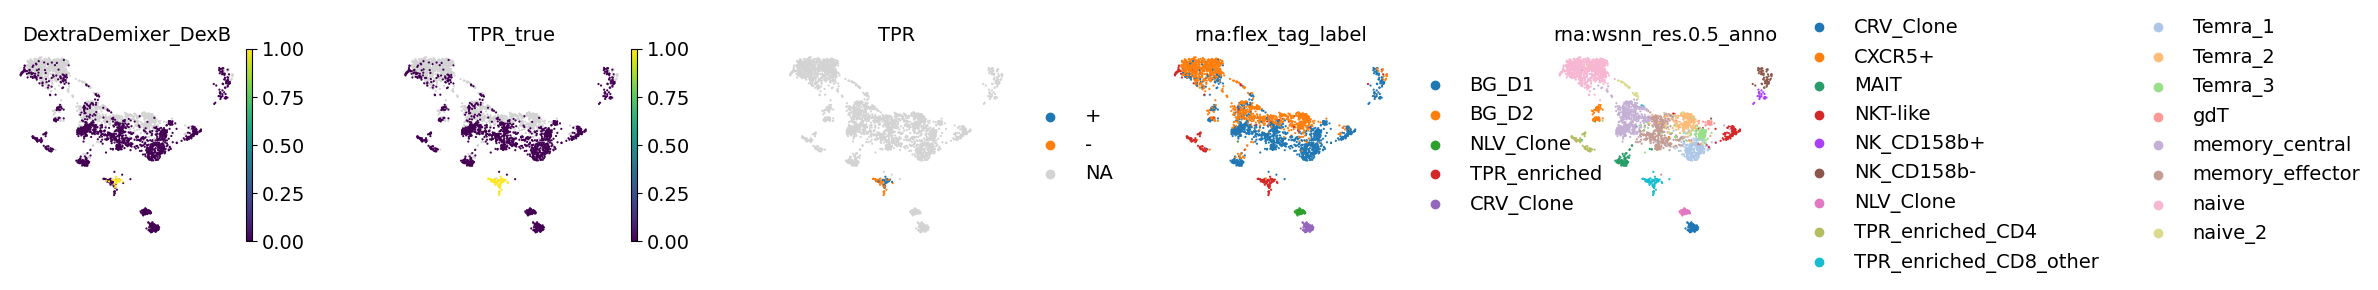

In [20]:
mdata_wTCR.obs['TPR'] = None
mdata_wTCR.obs.loc[mdata_wTCR.obs['TPR_true'] == 1,'TPR'] = '-'
mdata_wTCR.obs.loc[mdata_wTCR.obs['DextraDemixer_DexB'] == 1,'TPR'] = '+'

mu.pl.embedding(
    mdata_wTCR, basis='rna:wnn.umap', color=['DextraDemixer_DexB','TPR_true','TPR', 'rna:flex_tag_label', 'rna:wsnn_res.0.5_anno'], 
    ncols=5, wspace=0.5, frameon=False, s=10, show=True
)

In [21]:
mdata_wTCR.obs['TPR'].value_counts()

TPR
-    57
+    29
Name: count, dtype: int64

In [22]:
# Import T cell gene sets
tcat = starCAT(reference='TCAT.V1', cachedir='./cache')
tcat.ref.index

# From starCat
mdata_wTCR.mod['rna'].X = mdata_wTCR.mod['rna'].layers['data']
usage, scores = tcat.fit_transform(mdata_wTCR.mod['rna'])

# Signatures significantly associated to antigen specific activation in the starCat paper
act_cols = [
    'CellCycle-G2M', 'CellCycle-S', 'CellCycle-Late-S', 'HLA', 'Cytoskeleton', 'Heatshock',
    'Multi-Cytokine', 'ICOS/CD38', 'NME1/FABP5', 'RGCC/MYADM', 'TIMD4/TIM3', 'BCL2/FAM13A'
]

Using reference from starCAT database
Loading reference from existing cache file for reference TCAT.V1


/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/starcat/starcat.py:244: UserWarning: WARNING!: query input is not an integer count matrix as expected.
            Please provide an integer count matrix unless you are sure you know what you are doing.
  warnings.warn("""WARNING!: query input is not an integer count matrix as expected.
/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/starcat/starcat.py:253: UserWarning: WARNING!: query input has 105 genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.
  warnings.warn("""WARNING!: query input has %d genes with 0 counts after overlapping with query. Normalized values for these genes are set to 0.""" % num_zeros, UserWarning)


3250 out of 3412 genes in the reference overlap with the query


/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.0.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [23]:
def custom_mean(df, skipna=False):
    return df.mean(skipna=skipna)
def custom_sd(df, skipna=False):
    return df.std(skipna=skipna)

tpr_obs = pd.concat([mdata_wTCR.mod['airr'].obs, usage[act_cols]], axis=1)
tpr_obs['DexB'] = mdata_wTCR.obs.TPR.values
tpr_obs = tpr_obs[~tpr_obs.DexB.isna()]
gp_mean = tpr_obs[act_cols].groupby(tpr_obs.DexB).apply(lambda x: custom_mean(x,skipna=True)).T
gp_sd = tpr_obs[act_cols].groupby(tpr_obs.DexB).apply(lambda x: custom_sd(x,skipna=True)).T
gp_results = pd.concat([gp_mean,gp_sd], axis=1)
gp_results.columns = gp_results.columns + [' mean',' mean',' SD',' SD']
gp_results['Pval'] = np.nan
gp_results['Tval'] = np.nan

for score in act_cols:
    tval, pval = ttest_ind(tpr_obs.loc[tpr_obs.DexB=='+',score].values, tpr_obs.loc[tpr_obs.DexB=='-',score].values)
    gp_results.loc[score,['Tval','Pval']] = [tval, pval]

gp_results['FDR'] = false_discovery_control(gp_results.Pval.values)
significant_GPs = gp_results.index[gp_results.FDR<0.05]
print(significant_GPs)
gp_long = tpr_obs[['DexB']+significant_GPs.tolist()].melt(id_vars='DexB', var_name='GP', value_name='Score')
gp_results.sort_values(by='FDR')

Index(['CellCycle-G2M', 'HLA', 'Heatshock', 'NME1/FABP5'], dtype='object')


DexB,+ mean,- mean,+ SD,- SD,Pval,Tval,FDR
NME1/FABP5,0.057619,0.010611,0.058426,0.014530,1.324731e-07,5.763613,0.000002
HLA,0.025369,0.009893,0.014748,0.012188,1.495224e-06,5.180527,0.000009
Heatshock,0.020412,0.011308,0.010960,0.007212,1.385357e-05,4.617378,0.000055
CellCycle-G2M,0.055870,0.025458,0.057160,0.043345,7.189113e-03,2.755288,0.021567
CellCycle-S,0.080802,0.058250,0.059629,0.066572,1.281379e-01,1.536648,0.307531
CellCycle-Late-S,0.039850,0.029135,0.040931,0.042512,2.664560e-01,1.118703,0.456782
ICOS/CD38,0.011520,0.014544,0.006029,0.012689,2.284812e-01,-1.213128,0.456782
Cytoskeleton,0.006882,0.008841,0.006230,0.010576,3.613108e-01,-0.917878,0.481748
Multi-Cytokine,0.015167,0.011948,0.015317,0.014922,3.511538e-01,0.937569,0.481748
BCL2/FAM13A,0.012046,0.013006,0.005230,0.008685,5.863995e-01,-0.546166,0.703679


In [24]:
# Compare receptors to VDJ-db
vdjdb = ir.datasets.vdjdb()
ir.pp.ir_dist(mdata_wTCR.mod['airr'], reference=vdjdb, metric='identity', sequence='aa')
ir.tl.ir_query(mdata_wTCR.mod['airr'], vdjdb, metric='identity', sequence='aa', receptor_arms='any', dual_ir='any')

In [25]:
# Match level
vdj_matches = ir.tl.ir_query_annotate_df(mdata_wTCR.mod['airr'], vdjdb, metric="identity", sequence="aa", include_ref_cols=["antigen.species", "antigen.gene", "antigen.epitope"],)
vdj_matches = vdj_matches.loc[vdj_matches.index.isin(tpr_obs.index),]
vdj_matches.loc[:,['TPR','Ambiguous','Unknown']] = False
vdj_matches.loc[vdj_matches['antigen.epitope'] == 'TPRVTGGGAM','TPR'] = True
vdj_matches.loc[vdj_matches.TPR == 0 ,'Other'] = True # If they don't bind TPR, they bind somehting else

# Cell level
vdj_matches = vdj_matches.groupby(vdj_matches.index)[['TPR','Other','Ambiguous','Unknown']].sum() > 0
vdj_matches.loc[vdj_matches.sum(axis=1) == 2 ,'Ambiguous'] = True # If they bind TPR and other, they are ambiguous
vdj_matches.loc[vdj_matches.Ambiguous,['TPR','Other']] = False
vdj_matches = vdj_matches.reindex(tpr_obs.index, fill_value=False) # Include all cells
vdj_matches.loc[vdj_matches.sum(axis=1) == 0 ,'Unknown'] = True # No match

In [26]:
tpr_obs['Specificity'] = vdj_matches.idxmax(axis=1)

clones = tpr_obs[['clone_id','DexB','Specificity']].value_counts().reset_index().rename(columns={'count': 'clone_id_size'})
counts = clones[['DexB','clone_id_size']].value_counts().reset_index()
counts = counts.rename(columns={'clone_id_size': 'Expansion', 'count': 'Amount of clones'})

specificity = tpr_obs[['DexB','Specificity']].value_counts().reset_index()
specificity = specificity[specificity.Specificity != 'Unknown']
specificity['Specificity'] = pd.Categorical(
    specificity['Specificity'], categories=['TPR','Other','Ambiguous']
)
specificity = specificity.pivot(columns='Specificity', index='DexB', values='count').fillna(0)
specificity = specificity.div(specificity.sum(axis=1), axis=0)
clones.head(3)

,clone_id,DexB,Specificity,clone_id_size
0,21,+,TPR,11
1,83,-,Unknown,3
2,39,-,Other,2


In [27]:
tpr_obs[['DexB','Specificity']].value_counts().reset_index()

,DexB,Specificity,count
0,-,Unknown,44
1,+,TPR,13
2,+,Unknown,13
3,-,Other,12
4,+,Other,2
5,+,Ambiguous,1
6,-,Ambiguous,1


In [28]:
specificity

Specificity,TPR,Other,Ambiguous
DexB,,,
+,0.8125,0.125000,0.062500
-,0.0000,0.923077,0.076923


/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/muon/_core/plot.py:263: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{key}_colors"] = ad.uns[f"{col}_colors"]
/var/folders/l3/n75m9_cn5lzbx_tm88xrzhmhcfmwpj/T/ipykernel_99613/4469533.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=25, horizontalalignment='right')


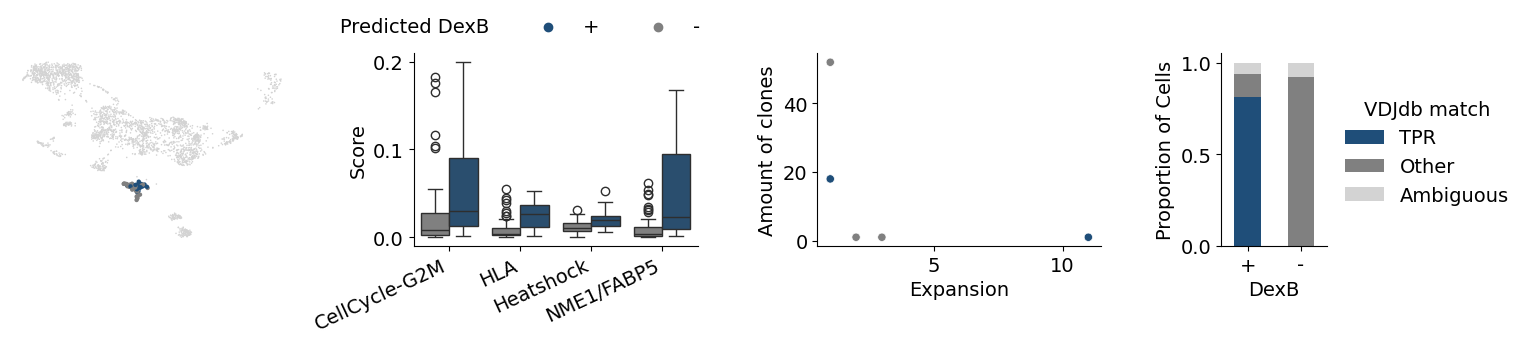

In [29]:
fig = plt.figure(figsize=(17, 2.5))
gs = fig.add_gridspec(1, 4, width_ratios=[2, 2, 2, 0.75], wspace=0.5)
axes = [fig.add_subplot(gs[0,i]) for i in range(4)]

axes[0] = mu.pl.embedding(
    mdata_wTCR, basis='rna:wnn.umap', palette='lightgray', frameon=False, s=5, show=False, title=[''], ax=axes[0]
)

axes[0] = mu.pl.embedding(
    mdata_wTCR[~mdata_wTCR.obs.TPR.isna()], basis='rna:wnn.umap', color=['TPR'], frameon=False, s=40, show=False, 
    palette=['#1F4E79', 'gray'], title=[''], ax=axes[0]
)

leg_handles, leg_labels = axes[0].get_legend_handles_labels()
handles = [plt.Line2D([], [], linestyle='')] + [h for h, l in zip(leg_handles, leg_labels) if l != 'NA']
labels = ['Predicted DexB'] + [l for h, l in zip(leg_handles, leg_labels) if l != 'NA']
axes[0].legend(handles, labels, loc='lower center', frameon=False, ncols=3, bbox_to_anchor=(1.7, 1.0))

axes[1] = sns.boxplot(gp_long, hue='DexB', y='Score', x='GP', palette=['gray', '#1F4E79'], fill=True, ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(),rotation=25, horizontalalignment='right')
axes[1].legend_.remove()

axes[2] = sns.scatterplot(data=counts, y='Amount of clones', x='Expansion', hue='DexB', palette=['gray', '#1F4E79'], ax=axes[2])
axes[2].legend_.remove()

axes[3] = specificity.plot(kind='bar', stacked=True, legend=False, ax=axes[3], color=["#1F4E79",'gray','lightgray'])
axes[3].legend(bbox_to_anchor=(1, 0.85), frameon=False, title="VDJdb match")
axes[3].set_ylabel('Proportion of Cells')
axes[3].set_xticklabels(axes[3].get_xticklabels(),rotation=0, horizontalalignment='center')

plt.savefig('../../figures/3d-g.svg')
plt.show()

In [30]:
ir.get.airr(
    mdata_wTCR[mdata_wTCR.obs['airr:clone_id']=='21'],
    ["junction_aa", "v_call", "j_call"],
    chain=["VJ_1", "VDJ_1"],
).head(1)

,VJ_1_junction_aa,VJ_1_v_call,VJ_1_j_call,VDJ_1_junction_aa,VDJ_1_v_call,VDJ_1_j_call
cell_id,,,,,,
CCACTTGGAAGGTTCGCTACAACTAGT_1,CATVLRMDSSYKLIF,TRAV17*00,TRAJ12*00,CASSLLGISTYNEQFF,TRBV7-9*00,TRBJ2-1*00


In [31]:
ir.get.airr(
    mdata_wTCR[mdata_wTCR.obs['airr:clone_id']=='83'],
    ["junction_aa", "v_call", "j_call"],
    chain=["VJ_1", "VDJ_1"],
).head(1)

,VJ_1_junction_aa,VJ_1_v_call,VJ_1_j_call,VDJ_1_junction_aa,VDJ_1_v_call,VDJ_1_j_call
cell_id,,,,,,
GGCAAGCAATGTTCTCCAAGTCTGTAC_1,CAVHNARLMF,TRAV21*00,TRAJ31*00,CASSLDSRGSNTEAFF,TRBV7-2*00,TRBJ1-1*00


In [32]:
ir.get.airr(
    mdata_wTCR[mdata_wTCR.obs['airr:clone_id']=='39'],
    ["junction_aa", "v_call", "j_call"],
    chain=["VJ_1", "VDJ_1"],
).head(1)

,VJ_1_junction_aa,VJ_1_v_call,VJ_1_j_call,VDJ_1_junction_aa,VDJ_1_v_call,VDJ_1_j_call
cell_id,,,,,,
CAGCTGACAAACCAAAGTAATGTATCG_1,CAASEAAGNKLTF,TRAV29DV5*00,TRAJ17*00,CASSPVSQGVRYNEQFF,TRBV28*00,TRBJ2-1*00
